In [1]:
using DifferentialEquations
using PyPlot
using PyCall

In [2]:
function ODEwrap(func, y0, params, t, abstol = 1E-20, reltol = 1E-22)
   prob = ODEProblem(func, y0 , (t[1],t[end]), saveat = t; abstol = abstol, reltol = reltol) 
   sol_temp = solve(prob, p = params, maxiters = Inf);
   sol = [sol_temp.u[i][j] for i =1:length(t), j=1:length(y0)]'
   return sol_temp.t, sol
end

function dynamics_normalized!(dy,y,p,t)
    ξ,γ = p
    dy[1] = (2*y[2] - ξ - γ)*y[1] 
    dy[2] = -y[1] - γ*(y[2] + 1/2)
end

function dynamics!(dy,y,p,t)
    ξ,γ,N = p
    dy[1] = (y[2]*2*N - ξ - γ)*y[1]
    dy[2] = -y[1]*N - γ*(y[2] + 1/2)
end

function dynamics_nonnormalized!(dy,y,p,t)
    ξ,γ = p
    dy[1] = (2*y[2] - ξ)*y[1] 
    dy[2] = -y[1]
end

function dynamics_linearized!(dy,y,p,t)
    ξ,γ = p
    dy[1] = (2*y[2] - ξ - γ)*y[1] 
    dy[2] = -γ*(y[2] + 0.5)
end


function triangle_traj(sol)
    return sqrt.(sol[1,:] + sol[2,:].^2), sol[2,:]
end

function phasediagramsweep(N)
    y0 = [1/N,1/2]
    t = LinRange(0,100,5000)
    γnew = LinRange(0,1.1,250)
    ξnew = LinRange(0,1.1,250)
    temp = zeros((length(γnew),length(ξnew)))
    prob = ODEProblem(dynamics_normalized!, y0 , (t[1],t[end]), saveat = t; abstol = 1E-18, reltol = 1E-20) 
    for i=1:length(ξnew)
        for j=1:length(γnew)
            t_temp, sol = solve(prob, p=[ξnew[i],γnew[j]])
            temp[i,j] = maximum(sol[1,:])
        end
    end
    return temp
end

function colormap_colors(name::String, n::Int)
    cmap = get_cmap(name)
    xs = range(0, 1, length=n)
    [cmap(x) for x in xs]
end

function marker_coords(marker_pos,s,m)
    temp_posx = []
    temp_posy = []
    temp_angle = []
    for i=1:length(marker_pos)
        mpos = marker_pos[i]
        ind = argmin(abs.(m .- mpos))
        push!(temp_posx,s[ind])
        push!(temp_posy,m[ind])
        slope = (m[ind+1] - m[ind])/(s[ind+5] - s[ind])
        temp_angle = [atan(1/slope)]
    end
    return temp_posx, temp_posy, temp_angle
end

macro R_str(s)
    return s
end

function β(gx,ggbar, x, gg = 0) 
    temp  = 1 .+ (1 .- gx .- gg .- (1 .+ gx .+ gg).*log.(2 ./(1 .+ gx .+ gg)))./ggbar
    #mask1 = temp .< 2
    return temp
end

function fix_subplot_sizes!(axs, widths_cm, heights_cm;
                            hgap_cm=0.3, vgap_cm=0.3,
                            outer_cm=(0.2,0.2,0.2,0.2),
                            pad_pt=4, layout::Symbol=:auto)

    # --- Normalize axs to a 2D Matrix{PyObject} and get (nrows, ncols)
    _to_matrix = function(axs, layout)
        if axs isa AbstractMatrix
            return axs, size(axs)
        elseif axs isa AbstractVector
            # Decide row vs column layout
            lay = layout === :auto ? :row : layout
            if lay === :row
                A = reshape(axs, 1, length(axs))
            elseif lay === :col
                A = reshape(axs, length(axs), 1)
            else
                throw(ArgumentError("layout must be :auto, :row, or :col"))
            end
            return A, size(A)
        elseif axs isa PyObject
            A = reshape([axs], 1, 1)
            return A, size(A)
        else
            # Try to coerce anything iterable of axes
            V = collect(axs)
            if length(V) == 1
                A = reshape(V, 1, 1)
            else
                # default to a single row
                A = reshape(V, 1, length(V))
            end
            return A, size(A)
        end
    end

    axsM, (nrows, ncols) = _to_matrix(axs, layout)
    fig = axsM[1,1].figure
    dpi = fig.get_dpi()

    # Normalize widths/heights to per-col/per-row vectors
    wcols = isa(widths_cm, Number)  ? fill(Float64(widths_cm), ncols)  : collect(Float64.(widths_cm))
    hrows = isa(heights_cm, Number) ? fill(Float64(heights_cm), nrows) : collect(Float64.(heights_cm))
    @assert length(wcols) == ncols "length(widths_cm) must equal ncols=$ncols"
    @assert length(hrows) == nrows "length(heights_cm) must equal nrows=$nrows"

    # Units
    cm2in(x) = x/2.54
    pad_in   = pad_pt/72

    wcols_in = cm2in.(wcols)
    hrows_in = cm2in.(hrows)
    hgap_in  = cm2in(hgap_cm)
    vgap_in  = cm2in(vgap_cm)
    left_out_in, right_out_in, bottom_out_in, top_out_in = cm2in.(outer_cm)

    # First draw to get renderer and bboxes
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # Decorations per axes (inches)
    left_dec   = zeros(nrows, ncols)
    right_dec  = zeros(nrows, ncols)
    bottom_dec = zeros(nrows, ncols)
    top_dec    = zeros(nrows, ncols)

    for i in 1:nrows, j in 1:ncols
        ax = axsM[i,j]
        bb_axes  = ax.get_window_extent(renderer=renderer)
        bb_tight = ax.get_tightbbox(renderer, call_axes_locator=true)

        to_in = x -> x/dpi
        ax_x0, ax_y0, ax_x1, ax_y1 = to_in(bb_axes.x0),  to_in(bb_axes.y0),  to_in(bb_axes.x1),  to_in(bb_axes.y1)
        ti_x0, ti_y0, ti_x1, ti_y1 = to_in(bb_tight.x0), to_in(bb_tight.y0), to_in(bb_tight.x1), to_in(bb_tight.y1)

        left_dec[i,j]   = max(0.0, ax_x0 - ti_x0) + pad_in
        right_dec[i,j]  = max(0.0, ti_x1 - ax_x1) + pad_in
        bottom_dec[i,j] = max(0.0, ax_y0 - ti_y0) + pad_in
        top_dec[i,j]    = max(0.0, ti_y1 - ax_y1) + pad_in
    end

    # Max decoration required per column and per row
    col_left  = [maximum(left_dec[:,j])   for j in 1:ncols]
    col_right = [maximum(right_dec[:,j])  for j in 1:ncols]
    row_bot   = [maximum(bottom_dec[i,:]) for i in 1:nrows]
    row_top   = [maximum(top_dec[i,:])    for i in 1:nrows]

    # Total figure size (inches)
    total_w_in = left_out_in + sum(col_left .+ wcols_in .+ col_right) + hgap_in*max(ncols-1, 0) + right_out_in
    total_h_in = bottom_out_in + sum(row_bot .+ hrows_in .+ row_top) + vgap_in*max(nrows-1, 0) + top_out_in

    fig.set_size_inches(total_w_in, total_h_in, forward=true)

    # X origins per column
    x0_cols = zeros(ncols)
    x = left_out_in
    for j in 1:ncols
        x += col_left[j]
        x0_cols[j] = x
        x += wcols_in[j] + col_right[j]
        if j < ncols; x += hgap_in; end
    end

    # Y origins per row (origin bottom)
    y0_rows = zeros(nrows)
    y = bottom_out_in
    for i in 1:nrows
        y += row_bot[i]
        y0_rows[i] = y
        y += hrows_in[i] + row_top[i]
        if i < nrows; y += vgap_in; end
    end

    # Apply positions
    for i in 1:nrows, j in 1:ncols
        left   = x0_cols[j] / total_w_in
        bottom = y0_rows[i] / total_h_in
        width  = wcols_in[j] / total_w_in
        height = hrows_in[i] / total_h_in
        axsM[i,j].set_position([left, bottom, width, height])
    end

    fig.canvas.draw()
    nothing
end

fix_subplot_sizes! (generic function with 1 method)

In [3]:
rc("font",
    family="serif",
    serif=["Times New Roman"],
    size=8)

rc("mathtext",
    fontset="cm")

In [4]:
N = 1E10
y0 = [1/N,1/2]
tburst = log(N)

23.025850929940457

In [5]:
t = 10 .^(-2:0.001:3)
x = LinRange(0,1.15,13)
ξfactor = 4
ξs = x
γs = x/log(N)/ξfactor
sols = zeros((length(ξs), 2, length(t)))


for i = 1:length(ξs)
    t, temp = ODEwrap(dynamics_normalized!, y0, [ξs[i],γs[i]], t)
    sols[i,:,:] = temp
end

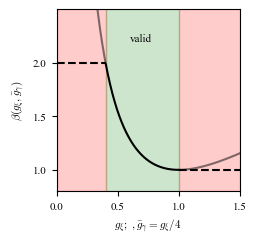

PyObject <matplotlib.collections.FillBetweenPolyCollection object at 0x1686ac7d0>

In [ ]:
xcont = LinRange(0,1.7,1000)

gxcont = xcont
ggcont = xcont/ξfactor

tempy = β(gxcont, ggcont, xcont)
bdry1 = xcont[argmin(abs.(tempy .- 2))]
bdry2 = xcont[argmin(abs.(tempy .- 1))]


cm = 1/2.54
fs = 8

xmin,xmax = 0,1.5
ymin,ymax = 0.8,2.5

fig,ax = plt.subplots(figsize = (6*cm,6*cm))
mask1 = xcont .< bdry1
mask2 = xcont .> bdry2
mask = ((xcont .> bdry1) .&& (xcont .< bdry2))
ax.plot(xcont[mask], tempy[mask], color = "black")
ax.plot(xcont[mask1], tempy[mask1], color = "black", alpha = 0.5)
ax.plot(xcont[mask2], tempy[mask2], color = "black", alpha = 0.5)
ax.set_ylim(ymin,ymax)
ax.set_xlim(xmin,xmax)
ax.set_yticks(1.0:0.5:2.0)
ax.plot([0,bdry1],[2,2], ls = "--", color = "black")
ax.plot([bdry2,2],[1,1], ls = "--", color = "black")
ax.text(0.6,2.2,"valid", fontsize = fs)
ax.set_ylabel(R"$\beta (g_\xi,\bar{g}_\gamma)$", fontsize = fs)
ax.set_xlabel(R"$g_\xi;\;,\bar{g}_\gamma =g_\xi/4$", fontsize = fs)
ax.fill_between([0,bdry1], [ymin,ymin],[ymax,ymax], color = "red",alpha = 0.2)
ax.fill_between([bdry1,bdry2], [ymin,ymin],[ymax,ymax], color = "green",alpha = 0.2)
ax.fill_between([bdry2,xmax], [ymin,ymin],[ymax,ymax], color = "red",alpha = 0.2)
plt.savefig("../data/figS1d.pdf", bbox_inches = "tight")

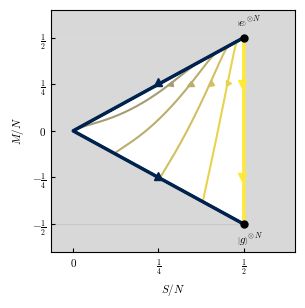

In [ ]:
cm = 1/2.54
fs = 8
fig,ax = plt.subplots(figsize = (8*cm,8*cm))
colors = colormap_colors("cividis_r", length(x))
lws = vcat([2.5],ones(length(x)-2)*1.5,[2.5])

mmarker = [0.25]
for i =1:length(ξs)
    tempx, tempy = triangle_traj(sols[i,:,:]) 
    ax.plot(tempx, tempy, color = colors[i], lw = lws[i])
    if i>1 && i <6
        for k=1:length(mmarker)
            mx,my,mθ = marker_coords(mmarker[k], tempx, tempy)
            rot =  matplotlib.transforms.Affine2D().rotate_deg(-mθ[1]*180/π)
            ax.plot(mx[1],my[1],marker=matplotlib.markers.MarkerStyle("v","full", rot),ms = 4, color = colors[i])
        end
    end
end

ax.set_xticks(0:0.25:0.5)
ax.set_xticklabels([R"$0$",R"$\frac{1}{4}$",R"$\frac{1}{2}$"],fontsize = fs)
ax.set_yticks(-0.5:0.25:0.5)
ax.set_yticklabels([R"$-\frac{1}{2}$",R"$-\frac{1}{4}$",R"$0$",R"$\frac{1}{4}$",R"$\frac{1}{2}$"],fontsize = fs)




trmax = 0.65
ax.fill_betweenx([-0.5,0, 0.5], [-0.1,-0.1*trmax,-0.1*trmax],[0.5,0,0.5], color = "grey", alpha = 0.3, lw = 0)
ax.fill_betweenx([-trmax, trmax], [0.5,0.5],[trmax,trmax], color = "grey", alpha = 0.3, lw = 0)
ax.fill_betweenx([0.5, trmax], -[0.1*trmax,0.1*trmax],[0.5,0.5], color = "grey", alpha = 0.3, lw = 0)
ax.fill_betweenx(-[0.5, trmax], -[0.1*trmax,0.1*trmax],[0.5,0.5], color = "grey", alpha = 0.3, lw = 0)


ax.set_xlim(-trmax*0.1,trmax)
ax.set_ylim(-trmax,trmax)
ax.set_xlabel(R"$S/N$")
ax.set_ylabel(R"$M/N$")
ax.set_xticks(0:0.25:0.5)
ax.set_xticklabels([R"$0$",R"$\frac{1}{4}$",R"$\frac{1}{2}$"],fontsize = fs)
ax.set_yticks(-0.5:0.25:0.5)
ax.set_yticklabels([R"$-\frac{1}{2}$",R"$-\frac{1}{4}$",R"$0$",R"$\frac{1}{4}$",R"$\frac{1}{2}$"],fontsize = fs)
ax.plot([0.5,0.5], [0.5,-0.5], "ko",ms = 5, zorder = 7)
ax.plot([0.495,0.495],[-0.25,0.25], "v",ms = 6, color = colors[1])
ax.plot([0.25,0.25],[-0.24,0.26], "^",ms = 6, color = colors[end])
ax.text(0.48,0.56, R"$\left|e\right>^{\otimes N}$",fontsize = fs)
ax.text(0.48,-0.6, R"$\left|g\right>^{\otimes N}$",fontsize = fs)
ax.tick_params(which = "both",direction = "in",length = 3)


plt.savefig("../data/fig1a.pdf", bbox_inches = "tight")

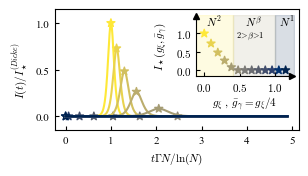

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x17bd99be0>

In [ ]:
fs = 8
cm = 1/2.54
xcont = LinRange(0,1.7,1000)
colors = colormap_colors("cividis_r", length(x))


fig,ax = plt.subplots(figsize = (8*cm,4*cm))

mask = t/log(N) .< 4.9
maxs = [maximum(sols[i,1,:]) for i=1:length(γs)]
maxinds = [argmax(sols[i,1,:]) for i=1:length(γs)]
for i =1:length(ξs) 
    ax.plot(t[mask]/log(N), sols[i,1,mask]/maxs[1], color = colors[i])
end


ax.scatter(t[maxinds]/log(N),maxs/maxs[1], color = colors, marker = "*")
ax.set_ylabel(R"$I(t)/I_\star^{(Dicke)}$", fontsize = fs)
ax.set_xlabel(R"$t\Gamma N/\ln(N)$", fontsize = fs)
ax.set_xticks(0:5)
ax.set_ylim(-0.15,1.15)
ax.tick_params(which = "both",direction = "in",length = 3)


yminaxins, ymaxaxins = -0.15, 1.5
xminaxins, xmaxaxins = maximum(x)*(-0.1), maximum(x)*1.1

axins = ax.inset_axes([0.58, 0.45, 0.4, 0.5])
axins.fill_between([xminaxins,bdry1],ones(2)*ymaxaxins, ones(2)*yminaxins, color = colors[1], alpha = 0.15, zorder = 0)
axins.fill_between([bdry1,bdry2],ones(2)*ymaxaxins, ones(2)*yminaxins, color = colors[5], alpha = 0.15, zorder = 0)
axins.fill_between([bdry2,xmaxaxins],ones(2)*ymaxaxins, ones(2)*yminaxins, color = colors[end], alpha = 0.15, zorder = 0)
axins.scatter(x,maxs/maxs[1], color = colors, marker ="*", zorder = 5)
axins.set_xlabel(R"$g_\xi\;,\;\bar{g}_\gamma = g_\xi/4$", fontsize = fs,labelpad = 1.5)
axins.set_ylabel(R"$I_\star(g_\xi,\bar{g}_\gamma)$", fontsize = fs)
axins.set_yticks(0:0.5:1)
axins.set_yticklabels([R"$0.0$",R"$0.5$",R"$1.0$"], fontsize = fs)
axins.set_xticks(0:0.5:1.0)
axins.set_xticklabels([R"$0.0$",R"$0.5$",R"$1.0$"], fontsize = fs)
axins.set_xlim(xminaxins, xmaxaxins)
axins.set_ylim(yminaxins, ymaxaxins)
axins.tick_params(which = "both",direction = "in",length = 3)
axins.text(0.025,1.2, R"$N^2$",fontsize = fs)
axins.text(0.57,1.2, R"$N^\beta$",fontsize = fs)
axins.text(0.45,0.9, R"$2\!>\!\beta\!>\!1$",fontsize = fs-2)
axins.text(1.05,1.2, R"$ N^1$",fontsize = fs)
axins.spines["right"].set_visible(false)
axins.spines["top"].set_visible(false)
axins.plot(xminaxins*0.99, ymaxaxins*0.98, "^k", clip_on = false, ms = 4)
axins.plot(xmaxaxins*0.98, yminaxins*0.98, ">k", clip_on = false, ms = 4)


plt.savefig("../data/fig1b.pdf", bbox_inches = "tight")

In [57]:
alternative_phasediag = phasediagramsweep(1E8);

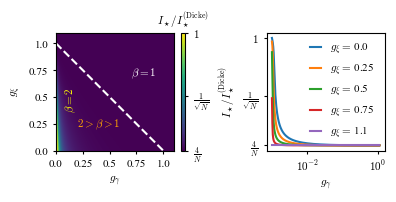

In [ ]:
γnew = LinRange(0,1.1,250) 
ξnew = LinRange(0,1.1,250)
fs = 8
cm = 1
fig, ax = plt.subplots(1,3)


im = ax[1].imshow(log10.(alternative_phasediag[end:-1:1,1:end]/alternative_phasediag[1,1]), extent = (0,1.1,0,1.1))
γN1 = LinRange(0,1,100)
ax[1].plot(γN1, 1 .- γN1, color = "white", ls = "--")
ax[1].text(0.7,0.7,R"$\beta = 1$", color = "white", fontweight = "bold", fontsize = fs)
ax[1].text(0.2,0.22,R"$2 >\beta > 1$", color = "orange", fontweight = "bold", fontsize = fs)
ax[1].text(0.07,0.4,R"$\beta = 2$", color = "yellow", fontweight = "bold", fontsize = fs, rotation = 90)
ax[1].set_xlabel(R"$g_\gamma$", fontsize = fs)
ax[1].set_ylabel(R"$g_\xi$",fontsize = fs)
ax[1].set_xticks(0:0.25:1)
ax[1].set_yticks(0:0.25:1)
ax[1].set_xticklabels(0:0.25:1, fontsize = fs)
ax[1].set_yticklabels(0:0.25:1, fontsize = fs)
cbar = fig.colorbar(im, cax=ax[2])


γN = 10 .^LinRange(-3, log10(1.1),250)
ξlines = [0,0.25,0.5,0.75,1.1]
inds = zeros(Int64,length(ξlines))
for i = 1:length(ξlines)
    inds[i] = Int64(argmin(abs.(ξnew .- ξlines[i])))
end
for i in inds
    ax[3].plot(γN,alternative_phasediag[i,:]./alternative_phasediag[1,1], label = R"$g_\xi =\,$"* string(round(digits = 2,ξnew[i])))
end
ax[3].legend(fontsize = fs, frameon = false, handlelength = 1)
ax[3].set_ylabel(R"$I_\star/I_\star^{\mathrm{(Dicke)}}$",fontsize =fs)
ax[3].set_xlabel(R"$g_\gamma$",fontsize = fs)
ax[3].loglog()


ax[2].set_title(R"$I_\star/I_\star^{\mathrm{(Dicke)}}$", fontsize = fs)
ax[2].set_yticks([0,-4,log10(4E-8)])
ax[2].set_yticklabels([R"$1$",R"$\frac{1}{\sqrt{N}}$",R"$\frac{4}{N}$"], fontsize = fs)


ax[3].set_xticks([1E-2,1E0])
ax[3].set_xticklabels([R"$10^{-2}$", R"$10^{0}$"], fontsize = fs)
ax[3].set_yticks([1,1E-4, 4E-8])
ax[3].set_yticklabels([R"$1$",R"$\frac{1}{\sqrt{N}}$",R"$\frac{4}{N}$"], fontsize = fs)


for i=1:3
    ax[i].tick_params(which = "both",direction = "out",length = 2)
end


fix_subplot_sizes!(ax, [3,3/25,3], [3], hgap_cm = 0.1,vgap_cm = 0.0, outer_cm = (0.0,0.0,0.0,0.0), pad_pt = 1)
plt.savefig("../data/figS2a.pdf", bbox_inches = "tight")